In [2]:
import pandas as pd
import numpy as np

# New 36-row dataset we are validating
new_path = "../data/analysis/lifecost_final_all_combinations_2026.csv"

# Current production dataset
old_path = "../data/processed/lifecost_final_2026.csv"

new_df = pd.read_csv(new_path)
old_df = pd.read_csv(old_path)

print("New dataset shape:", new_df.shape)
print("Old dataset shape:", old_df.shape)

display(new_df.head())

New dataset shape: (36, 13)
Old dataset shape: (29, 13)


,City,University,Course,Available,Duration_Years,Annual_Tuition_AUD,Monthly_Rent_AUD,Monthly_Food_AUD,Monthly_Transport_AUD,Monthly_Utilities_AUD,Monthly_Living_AUD,Annual_Living_AUD,Total_Masters_Cost_AUD
0,Melbourne,RMIT University,Master of Data Science,Yes,2.0,44160.0,1979.54,228.08,198.0,439.88,2845.5,34146.06,156612.12
1,Melbourne,RMIT University,Master of Information Technology,Yes,2.0,NaN,1979.54,228.08,198.0,439.88,2845.5,34146.06,NaN
2,Melbourne,RMIT University,Master of Business Administration,Yes,2.0,NaN,1979.54,228.08,198.0,439.88,2845.5,34146.06,NaN
3,Melbourne,Deakin University,Master of Data Science,Yes,2.0,44200.0,1979.54,228.08,198.0,439.88,2845.5,34146.06,156692.12
4,Melbourne,Deakin University,Master of Information Technology,Yes,2.0,44200.0,1979.54,228.08,198.0,439.88,2845.5,34146.06,156692.12


In [3]:
print("========== NEW DATASET OVERVIEW ==========")
print("Rows:", len(new_df))
print("Columns:", len(new_df.columns))

print("\nColumns:")
print(new_df.columns.tolist())

print("\nMissing values:")
display(new_df.isna().sum())

print("\nData types:")
display(new_df.dtypes)

print("\nFirst 10 records:")
display(new_df.head(10))

========== NEW DATASET OVERVIEW ==========
Rows: 36
Columns: 13

Columns:
['City', 'University', 'Course', 'Available', 'Duration_Years', 'Annual_Tuition_AUD', 'Monthly_Rent_AUD', 'Monthly_Food_AUD', 'Monthly_Transport_AUD', 'Monthly_Utilities_AUD', 'Monthly_Living_AUD', 'Annual_Living_AUD', 'Total_Masters_Cost_AUD']

Missing values:


City                       0
University                 0
Course                     0
Available                  0
Duration_Years             9
Annual_Tuition_AUD        16
Monthly_Rent_AUD           0
Monthly_Food_AUD           0
Monthly_Transport_AUD      0
Monthly_Utilities_AUD      0
Monthly_Living_AUD         0
Annual_Living_AUD          0
Total_Masters_Cost_AUD    18
dtype: int64


Data types:


City                          str
University                    str
Course                        str
Available                     str
Duration_Years            float64
Annual_Tuition_AUD        float64
Monthly_Rent_AUD          float64
Monthly_Food_AUD          float64
Monthly_Transport_AUD     float64
Monthly_Utilities_AUD     float64
Monthly_Living_AUD        float64
Annual_Living_AUD         float64
Total_Masters_Cost_AUD    float64
dtype: object


First 10 records:


,City,University,Course,Available,Duration_Years,Annual_Tuition_AUD,Monthly_Rent_AUD,Monthly_Food_AUD,Monthly_Transport_AUD,Monthly_Utilities_AUD,Monthly_Living_AUD,Annual_Living_AUD,Total_Masters_Cost_AUD
0,Melbourne,RMIT University,Master of Data Science,Yes,2.0,44160.0,1979.54,228.08,198.00,439.88,2845.50,34146.06,156612.12
1,Melbourne,RMIT University,Master of Information Technology,Yes,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,34146.06,NaN
2,Melbourne,RMIT University,Master of Business Administration,Yes,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,34146.06,NaN
3,Melbourne,Deakin University,Master of Data Science,Yes,2.0,44200.0,1979.54,228.08,198.00,439.88,2845.50,34146.06,156692.12
4,Melbourne,Deakin University,Master of Information Technology,Yes,2.0,44200.0,1979.54,228.08,198.00,439.88,2845.50,34146.06,156692.12
5,Melbourne,Deakin University,Master of Business Administration,Yes,2.0,50400.0,1979.54,228.08,198.00,439.88,2845.50,34146.06,169092.12
6,Melbourne,The University of Melbourne,Master of Data Science,Yes,2.0,57984.0,1979.54,228.08,198.00,439.88,2845.50,34146.06,184260.12
7,Melbourne,The University of Melbourne,Master of Information Technology,Yes,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,34146.06,NaN
8,Melbourne,The University of Melbourne,Master of Business Administration,Yes,2.0,56268.0,1979.54,228.08,198.00,439.88,2845.50,34146.06,180828.12
9,Sydney,UNSW Sydney,Master of Data Science,No,NaN,NaN,2403.33,218.51,217.39,435.00,3274.23,39290.76,NaN


In [4]:
# Show every City → University → Course combination
combinations = (
    new_df[
        [
            "City",
            "University",
            "Course",
            "Available",
            "Duration_Years",
            "Annual_Tuition_AUD",
        ]
    ]
    .sort_values(["City", "University", "Course"])
    .reset_index(drop=True)
)

display(combinations)

,City,University,Course,Available,Duration_Years,Annual_Tuition_AUD
0,Adelaide,Adelaide University,Master of Business Administration,Yes,1.5,54900.0
1,Adelaide,Adelaide University,Master of Data Science,Yes,2.0,57100.0
2,Adelaide,Adelaide University,Master of Information Technology,No,NaN,NaN
3,Brisbane,James Cook University,Master of Business Administration,Yes,1.5,33133.0
4,Brisbane,Queensland University of Technology,Master of Data Science,Yes,NaN,44200.0
5,Brisbane,Queensland University of Technology,Master of Information Technology,Yes,NaN,45000.0
6,Brisbane,University of Queensland,Master of Business Administration,Yes,1.5,69112.0
7,Brisbane,University of Queensland,Master of Data Science,Yes,2.0,60952.0
8,Brisbane,University of Queensland,Master of Information Technology,Yes,2.0,58056.0
9,Canberra,University of Canberra,Master of Business Administration,Yes,1.5,NaN


In [5]:
print("========== AVAILABILITY SUMMARY ==========")

print("Available:", (new_df["Available"].str.lower() == "yes").sum())
print("Unavailable:", (new_df["Available"].str.lower() == "no").sum())

print("\nBy city:")
display(
    new_df.groupby("City")["Available"]
    .value_counts()
    .unstack(fill_value=0)
)

print("\nBy course:")
display(
    new_df.groupby("Course")["Available"]
    .value_counts()
    .unstack(fill_value=0)
)

========== AVAILABILITY SUMMARY ==========
Available: 29
Unavailable: 7

By city:


Available,No,Yes
City,,
Adelaide,1,2
Brisbane,0,6
Canberra,1,2
Darwin,1,2
Hobart,3,0
Melbourne,0,9
Perth,0,3
Sydney,1,5



By course:


Available,No,Yes
Course,,
Master of Business Administration,1,11
Master of Data Science,2,10
Master of Information Technology,4,8


In [6]:
print("========== COST-RELATED COLUMNS ==========")

cost_keywords = [
    "rent",
    "food",
    "transport",
    "utilities",
    "living",
    "tuition",
    "duration",
    "cost"
]

cost_columns = [
    col for col in new_df.columns
    if any(keyword in col.lower() for keyword in cost_keywords)
]

print("\nCost-related columns:")
for col in cost_columns:
    print("-", col)

print("\nSample:")
display(new_df[cost_columns].head())

========== COST-RELATED COLUMNS ==========

Cost-related columns:
- Duration_Years
- Annual_Tuition_AUD
- Monthly_Rent_AUD
- Monthly_Food_AUD
- Monthly_Transport_AUD
- Monthly_Utilities_AUD
- Monthly_Living_AUD
- Annual_Living_AUD
- Total_Masters_Cost_AUD

Sample:


,Duration_Years,Annual_Tuition_AUD,Monthly_Rent_AUD,Monthly_Food_AUD,Monthly_Transport_AUD,Monthly_Utilities_AUD,Monthly_Living_AUD,Annual_Living_AUD,Total_Masters_Cost_AUD
0,2.0,44160.0,1979.54,228.08,198.0,439.88,2845.5,34146.06,156612.12
1,2.0,NaN,1979.54,228.08,198.0,439.88,2845.5,34146.06,NaN
2,2.0,NaN,1979.54,228.08,198.0,439.88,2845.5,34146.06,NaN
3,2.0,44200.0,1979.54,228.08,198.0,439.88,2845.5,34146.06,156692.12
4,2.0,44200.0,1979.54,228.08,198.0,439.88,2845.5,34146.06,156692.12


In [8]:
# ============================================
# COST CALCULATION VALIDATION
# ============================================

# Only available records
available_df = new_df[
    new_df["Available"].astype(str).str.lower().eq("yes")
].copy()

# ------------------------------------------------
# 1. Recalculate monthly living cost
# ------------------------------------------------

available_df["Calculated_Monthly_Living_AUD"] = (
    available_df["Monthly_Rent_AUD"]
    + available_df["Monthly_Food_AUD"]
    + available_df["Monthly_Transport_AUD"]
    + available_df["Monthly_Utilities_AUD"]
)

# ------------------------------------------------
# 2. Recalculate annual living cost
# ------------------------------------------------

available_df["Calculated_Annual_Living_AUD"] = (
    available_df["Calculated_Monthly_Living_AUD"] * 12
)

# ------------------------------------------------
# 3. Recalculate total Master's cost
# ------------------------------------------------
# Only possible when tuition + duration are available

available_df["Calculated_Total_Masters_Cost_AUD"] = (
    available_df["Annual_Tuition_AUD"]
    + available_df["Calculated_Annual_Living_AUD"]
) * available_df["Duration_Years"]

# ------------------------------------------------
# 4. Calculate differences
# ------------------------------------------------

available_df["Monthly_Living_Difference"] = (
    available_df["Calculated_Monthly_Living_AUD"]
    - available_df["Monthly_Living_AUD"]
)

available_df["Annual_Living_Difference"] = (
    available_df["Calculated_Annual_Living_AUD"]
    - available_df["Annual_Living_AUD"]
)

available_df["Masters_Cost_Difference"] = (
    available_df["Calculated_Total_Masters_Cost_AUD"]
    - available_df["Total_Masters_Cost_AUD"]
)

# ------------------------------------------------
# 5. Display validation
# ------------------------------------------------

validation_columns = [
    "City",
    "University",
    "Course",
    "Duration_Years",
    "Annual_Tuition_AUD",
    "Monthly_Rent_AUD",
    "Monthly_Food_AUD",
    "Monthly_Transport_AUD",
    "Monthly_Utilities_AUD",
    "Monthly_Living_AUD",
    "Calculated_Monthly_Living_AUD",
    "Monthly_Living_Difference",
    "Annual_Living_AUD",
    "Calculated_Annual_Living_AUD",
    "Annual_Living_Difference",
    "Total_Masters_Cost_AUD",
    "Calculated_Total_Masters_Cost_AUD",
    "Masters_Cost_Difference",
]

display(
    available_df[validation_columns].round(2)
)

,City,University,Course,Duration_Years,Annual_Tuition_AUD,Monthly_Rent_AUD,Monthly_Food_AUD,Monthly_Transport_AUD,Monthly_Utilities_AUD,Monthly_Living_AUD,Calculated_Monthly_Living_AUD,Monthly_Living_Difference,Annual_Living_AUD,Calculated_Annual_Living_AUD,Annual_Living_Difference,Total_Masters_Cost_AUD,Calculated_Total_Masters_Cost_AUD,Masters_Cost_Difference
0,Melbourne,RMIT University,Master of Data Science,2.0,44160.0,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,156612.12,156612.00,-0.12
1,Melbourne,RMIT University,Master of Information Technology,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,NaN,NaN,NaN
2,Melbourne,RMIT University,Master of Business Administration,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,NaN,NaN,NaN
3,Melbourne,Deakin University,Master of Data Science,2.0,44200.0,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,156692.12,156692.00,-0.12
4,Melbourne,Deakin University,Master of Information Technology,2.0,44200.0,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,156692.12,156692.00,-0.12
5,Melbourne,Deakin University,Master of Business Administration,2.0,50400.0,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,169092.12,169092.00,-0.12
6,Melbourne,The University of Melbourne,Master of Data Science,2.0,57984.0,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,184260.12,184260.00,-0.12
7,Melbourne,The University of Melbourne,Master of Information Technology,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,NaN,NaN,NaN
8,Melbourne,The University of Melbourne,Master of Business Administration,2.0,56268.0,1979.54,228.08,198.00,439.88,2845.50,2845.50,0.00,34146.06,34146.00,-0.06,180828.12,180828.00,-0.12
10,Sydney,UNSW Sydney,Master of Information Technology,2.0,63000.0,2403.33,218.51,217.39,435.00,3274.23,3274.23,0.00,39290.76,39290.76,0.00,204581.52,204581.52,0.00


In [9]:
# ============================================
# CELL 7 — CREATE CLEAN CALCULATED DATASET
# ============================================

calculated_df = new_df.copy()

# ------------------------------------------------
# 1. Calculate monthly living cost
# ------------------------------------------------

calculated_df["Calculated_Monthly_Living_AUD"] = (
    calculated_df["Monthly_Rent_AUD"]
    + calculated_df["Monthly_Food_AUD"]
    + calculated_df["Monthly_Transport_AUD"]
    + calculated_df["Monthly_Utilities_AUD"]
)

# ------------------------------------------------
# 2. Calculate annual living cost
# ------------------------------------------------

calculated_df["Calculated_Annual_Living_AUD"] = (
    calculated_df["Calculated_Monthly_Living_AUD"] * 12
)

# ------------------------------------------------
# 3. Calculate annual total cost
# ------------------------------------------------
# Only possible when tuition is available

calculated_df["Calculated_Annual_Total_AUD"] = np.where(
    calculated_df["Annual_Tuition_AUD"].notna(),
    calculated_df["Annual_Tuition_AUD"]
    + calculated_df["Calculated_Annual_Living_AUD"],
    np.nan
)

# ------------------------------------------------
# 4. Calculate total Master's cost
# ------------------------------------------------
# Requires BOTH tuition and duration

calculated_df["Calculated_Total_Masters_Cost_AUD"] = np.where(
    calculated_df["Annual_Tuition_AUD"].notna()
    & calculated_df["Duration_Years"].notna(),
    calculated_df["Calculated_Annual_Total_AUD"]
    * calculated_df["Duration_Years"],
    np.nan
)

# ------------------------------------------------
# 5. Round calculated values
# ------------------------------------------------

calculated_columns = [
    "Calculated_Monthly_Living_AUD",
    "Calculated_Annual_Living_AUD",
    "Calculated_Annual_Total_AUD",
    "Calculated_Total_Masters_Cost_AUD",
]

calculated_df[calculated_columns] = (
    calculated_df[calculated_columns].round(2)
)

# ------------------------------------------------
# 6. Display the result
# ------------------------------------------------

print("Calculated dataset shape:", calculated_df.shape)

display(
    calculated_df[
        [
            "City",
            "University",
            "Course",
            "Available",
            "Duration_Years",
            "Annual_Tuition_AUD",
            "Monthly_Rent_AUD",
            "Monthly_Food_AUD",
            "Monthly_Transport_AUD",
            "Monthly_Utilities_AUD",
            "Calculated_Monthly_Living_AUD",
            "Calculated_Annual_Living_AUD",
            "Calculated_Annual_Total_AUD",
            "Calculated_Total_Masters_Cost_AUD",
        ]
    ]
)

Calculated dataset shape: (36, 17)


,City,University,Course,Available,Duration_Years,Annual_Tuition_AUD,Monthly_Rent_AUD,Monthly_Food_AUD,Monthly_Transport_AUD,Monthly_Utilities_AUD,Calculated_Monthly_Living_AUD,Calculated_Annual_Living_AUD,Calculated_Annual_Total_AUD,Calculated_Total_Masters_Cost_AUD
0,Melbourne,RMIT University,Master of Data Science,Yes,2.0,44160.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,78306.00,156612.00
1,Melbourne,RMIT University,Master of Information Technology,Yes,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,34146.00,NaN,NaN
2,Melbourne,RMIT University,Master of Business Administration,Yes,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,34146.00,NaN,NaN
3,Melbourne,Deakin University,Master of Data Science,Yes,2.0,44200.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,78346.00,156692.00
4,Melbourne,Deakin University,Master of Information Technology,Yes,2.0,44200.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,78346.00,156692.00
5,Melbourne,Deakin University,Master of Business Administration,Yes,2.0,50400.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,84546.00,169092.00
6,Melbourne,The University of Melbourne,Master of Data Science,Yes,2.0,57984.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,92130.00,184260.00
7,Melbourne,The University of Melbourne,Master of Information Technology,Yes,2.0,NaN,1979.54,228.08,198.00,439.88,2845.50,34146.00,NaN,NaN
8,Melbourne,The University of Melbourne,Master of Business Administration,Yes,2.0,56268.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,90414.00,180828.00
9,Sydney,UNSW Sydney,Master of Data Science,No,NaN,NaN,2403.33,218.51,217.39,435.00,3274.23,39290.76,NaN,NaN


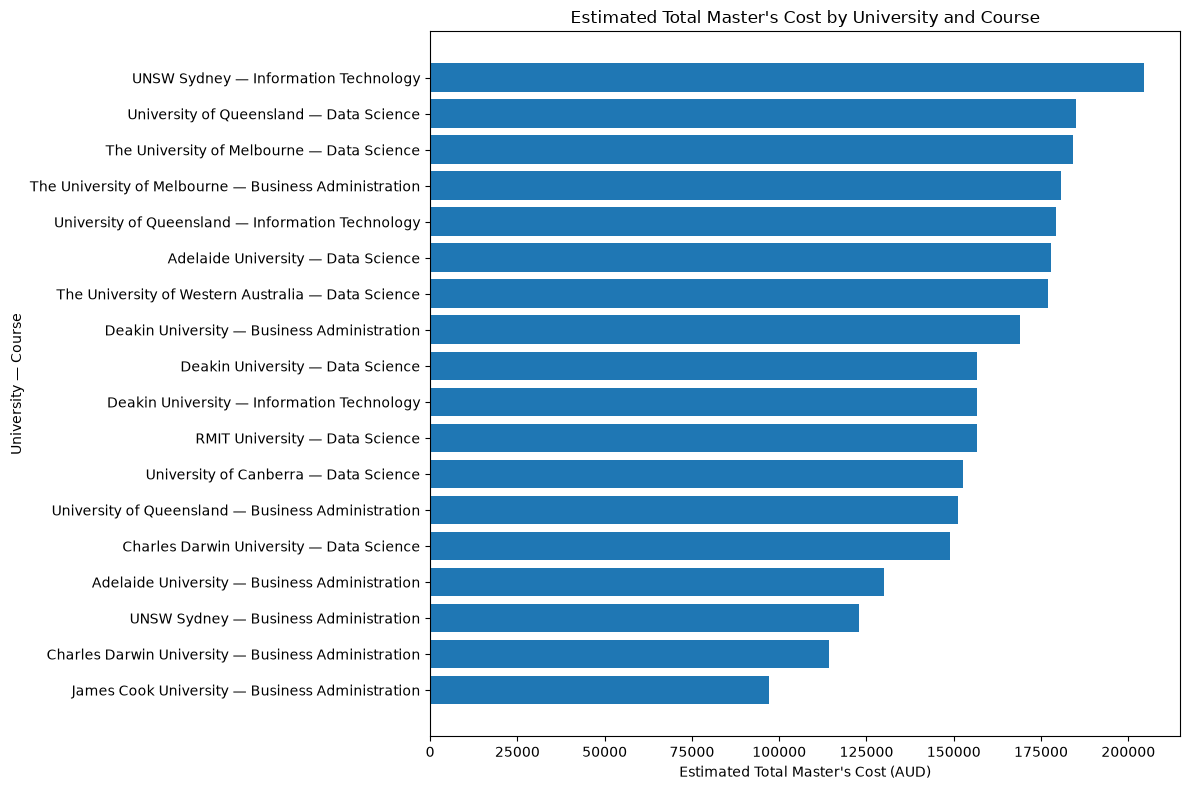

In [10]:
# ============================================
# CELL 8 — TOTAL MASTER'S COST COMPARISON
# ============================================

import matplotlib.pyplot as plt

# Only records where a meaningful Master's cost can be calculated
plot_df = calculated_df[
    (calculated_df["Available"].str.lower() == "yes")
    & calculated_df["Calculated_Total_Masters_Cost_AUD"].notna()
].copy()

# Create readable labels
plot_df["University_Course"] = (
    plot_df["University"]
    + " — "
    + plot_df["Course"].str.replace("Master of ", "", regex=False)
)

# Sort from lowest to highest cost
plot_df = plot_df.sort_values(
    "Calculated_Total_Masters_Cost_AUD"
)

plt.figure(figsize=(12, 8))

plt.barh(
    plot_df["University_Course"],
    plot_df["Calculated_Total_Masters_Cost_AUD"]
)

plt.xlabel("Estimated Total Master's Cost (AUD)")
plt.ylabel("University — Course")
plt.title("Estimated Total Master's Cost by University and Course")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

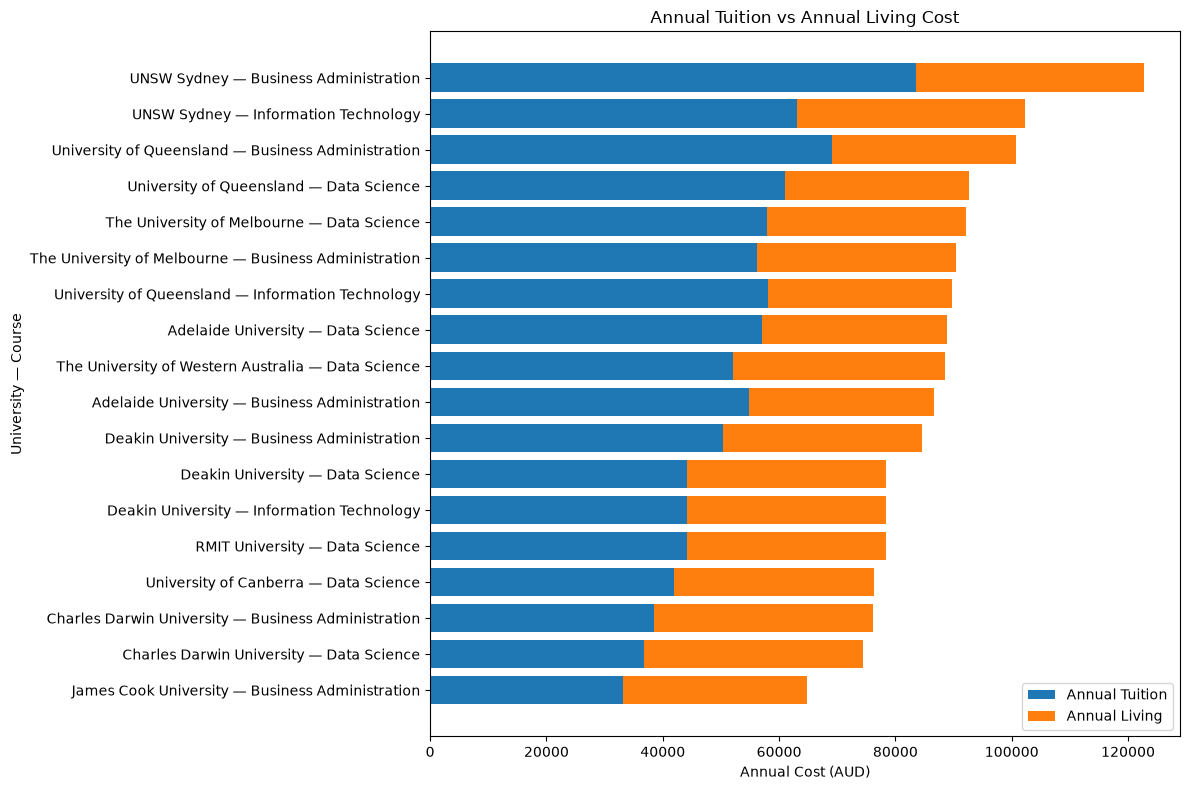

In [11]:
# ============================================
# CELL 9 — ANNUAL TUITION VS LIVING COST
# ============================================

cost_breakdown_df = calculated_df[
    (calculated_df["Available"].str.lower() == "yes")
    & calculated_df["Annual_Tuition_AUD"].notna()
    & calculated_df["Duration_Years"].notna()
].copy()

cost_breakdown_df["University_Course"] = (
    cost_breakdown_df["University"]
    + " — "
    + cost_breakdown_df["Course"].str.replace(
        "Master of ", "", regex=False
    )
)

cost_breakdown_df = cost_breakdown_df.sort_values(
    "Calculated_Annual_Total_AUD"
)

plt.figure(figsize=(12, 8))

plt.barh(
    cost_breakdown_df["University_Course"],
    cost_breakdown_df["Annual_Tuition_AUD"],
    label="Annual Tuition"
)

plt.barh(
    cost_breakdown_df["University_Course"],
    cost_breakdown_df["Calculated_Annual_Living_AUD"],
    left=cost_breakdown_df["Annual_Tuition_AUD"],
    label="Annual Living"
)

plt.xlabel("Annual Cost (AUD)")
plt.ylabel("University — Course")
plt.title("Annual Tuition vs Annual Living Cost")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

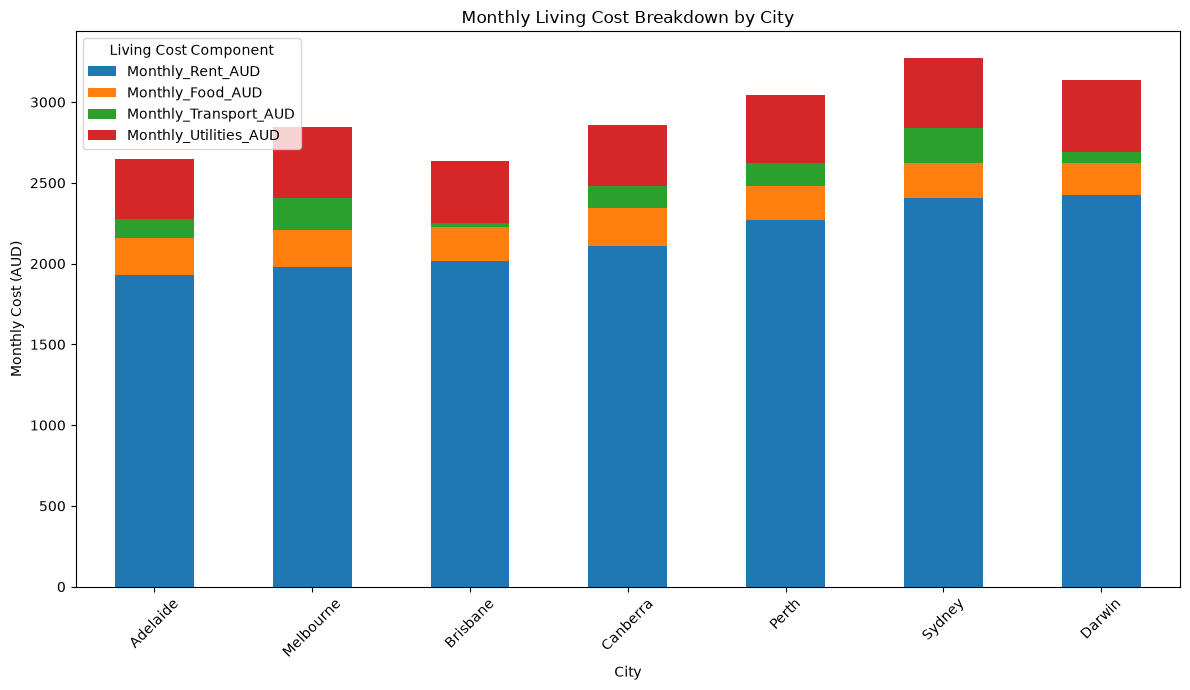

In [12]:
# ============================================
# CELL 10 — MONTHLY LIVING COST BREAKDOWN
# ============================================

living_df = calculated_df[
    (calculated_df["Available"].str.lower() == "yes")
].copy()

# Average living components by city
city_living = (
    living_df
    .groupby("City")[
        [
            "Monthly_Rent_AUD",
            "Monthly_Food_AUD",
            "Monthly_Transport_AUD",
            "Monthly_Utilities_AUD",
        ]
    ]
    .mean()
    .sort_values("Monthly_Rent_AUD")
)

# Plot
plt.figure(figsize=(12, 7))

city_living.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Monthly Living Cost Breakdown by City")
plt.xlabel("City")
plt.ylabel("Monthly Cost (AUD)")

plt.xticks(rotation=45)

plt.legend(
    title="Living Cost Component"
)

plt.tight_layout()
plt.show()

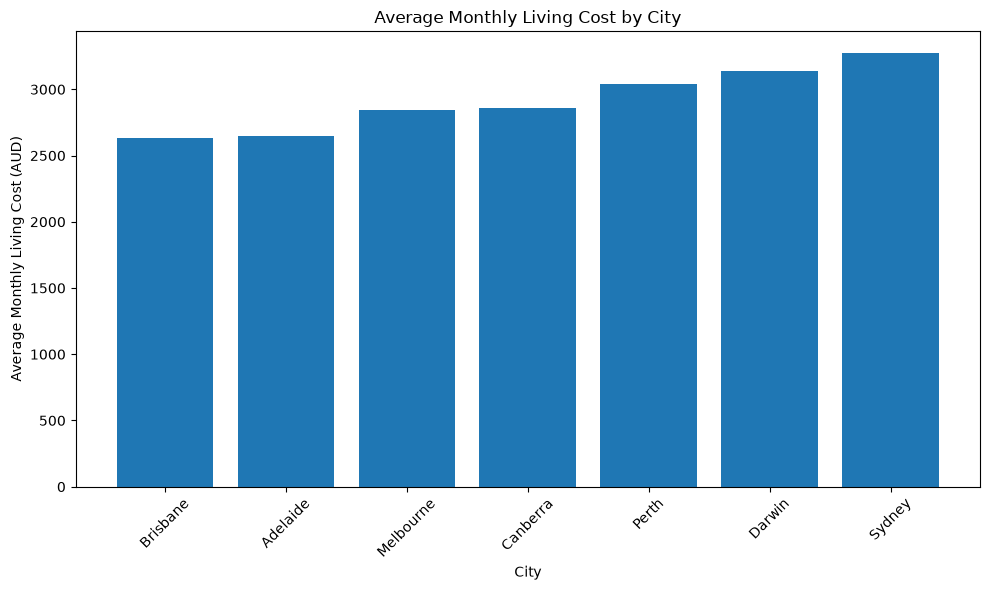

Average monthly living cost by city:


,Average_Monthly_Living_AUD
City,
Brisbane,2635.46
Adelaide,2649.93
Melbourne,2845.50
Canberra,2860.18
Perth,3043.06
Darwin,3137.44
Sydney,3274.23


In [13]:
# ============================================
# CELL 11 — TOTAL MONTHLY LIVING COST BY CITY
# ============================================

city_living_total = (
    calculated_df[
        calculated_df["Available"].str.lower() == "yes"
    ]
    .groupby("City")["Calculated_Monthly_Living_AUD"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.bar(
    city_living_total.index,
    city_living_total.values
)

plt.xlabel("City")
plt.ylabel("Average Monthly Living Cost (AUD)")
plt.title("Average Monthly Living Cost by City")

plt.xticks(rotation=45)

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

print("Average monthly living cost by city:")
display(
    city_living_total.round(2).to_frame(
        "Average_Monthly_Living_AUD"
    )
)

Course-wise Master's Cost Summary:


,Average_Total_Masters_Cost_AUD,Minimum_Total_Masters_Cost_AUD,Maximum_Total_Masters_Cost_AUD,Available_Complete_Combinations
Course,,,,
Master of Business Administration,137902.50,97137.78,180828.00,7
Master of Data Science,167388.96,148916.56,185155.04,8
Master of Information Technology,180212.19,156692.00,204581.52,3


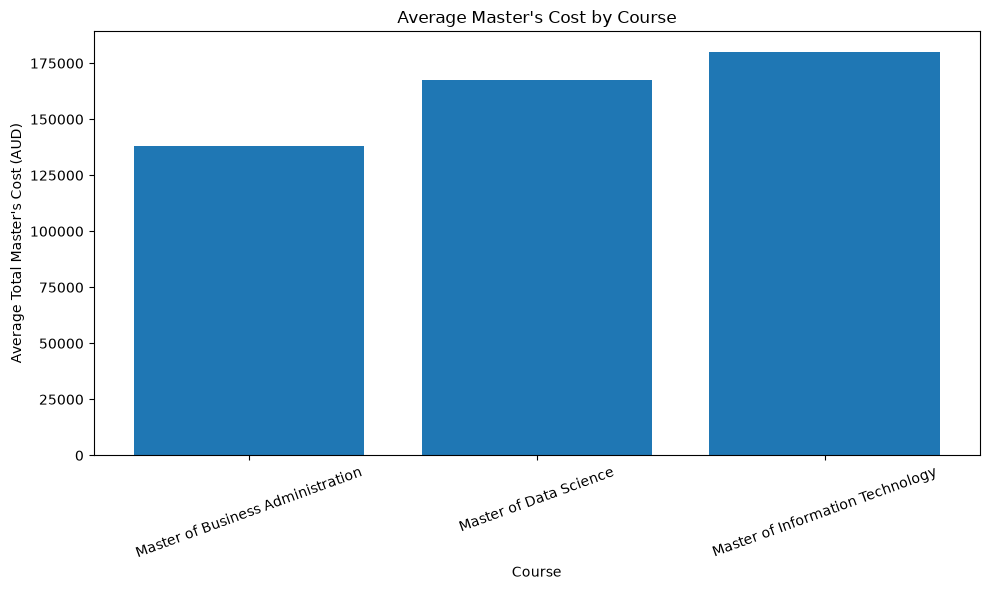

In [14]:
# ============================================
# CELL 12 — COURSE-WISE COST COMPARISON
# ============================================

course_cost_df = calculated_df[
    (calculated_df["Available"].str.lower() == "yes")
    & calculated_df["Annual_Tuition_AUD"].notna()
    & calculated_df["Duration_Years"].notna()
    & calculated_df["Calculated_Total_Masters_Cost_AUD"].notna()
].copy()

course_summary = (
    course_cost_df
    .groupby("Course")["Calculated_Total_Masters_Cost_AUD"]
    .agg(["mean", "min", "max", "count"])
    .sort_values("mean")
)

course_summary.columns = [
    "Average_Total_Masters_Cost_AUD",
    "Minimum_Total_Masters_Cost_AUD",
    "Maximum_Total_Masters_Cost_AUD",
    "Available_Complete_Combinations"
]

# Round values
course_summary = course_summary.round(2)

# Display summary
print("Course-wise Master's Cost Summary:")
display(course_summary)

# Plot average cost
plt.figure(figsize=(10, 6))

plt.bar(
    course_summary.index,
    course_summary["Average_Total_Masters_Cost_AUD"]
)

plt.xlabel("Course")
plt.ylabel("Average Total Master's Cost (AUD)")
plt.title("Average Master's Cost by Course")

plt.xticks(rotation=20)

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# CELL 13 — MISSING DATA REPORT
# ============================================

# ------------------------------------------------
# 1. Available courses with missing information
# ------------------------------------------------

available_missing = calculated_df[
    (calculated_df["Available"].str.lower() == "yes")
    & (
        calculated_df["Duration_Years"].isna()
        | calculated_df["Annual_Tuition_AUD"].isna()
    )
].copy()

# ------------------------------------------------
# 2. Add a column explaining what is missing
# ------------------------------------------------

def identify_missing(row):
    missing = []

    if pd.isna(row["Duration_Years"]):
        missing.append("Duration")

    if pd.isna(row["Annual_Tuition_AUD"]):
        missing.append("Tuition")

    return ", ".join(missing)


available_missing["Missing_Data"] = available_missing.apply(
    identify_missing,
    axis=1
)

# ------------------------------------------------
# 3. Display available combinations with missing data
# ------------------------------------------------

print("========== AVAILABLE COMBINATIONS WITH MISSING DATA ==========")

if len(available_missing) == 0:
    print("No available combinations have missing tuition or duration.")
else:
    display(
        available_missing[
            [
                "City",
                "University",
                "Course",
                "Available",
                "Duration_Years",
                "Annual_Tuition_AUD",
                "Missing_Data",
            ]
        ].sort_values(
            ["City", "University", "Course"]
        )
    )

# ------------------------------------------------
# 4. Unavailable combinations
# ------------------------------------------------

unavailable_df = calculated_df[
    calculated_df["Available"].str.lower() == "no"
].copy()

print("\n========== UNAVAILABLE COMBINATIONS ==========")

display(
    unavailable_df[
        [
            "City",
            "University",
            "Course",
            "Available",
            "Duration_Years",
            "Annual_Tuition_AUD",
        ]
    ].sort_values(
        ["City", "University", "Course"]
    )
)

# ------------------------------------------------
# 5. Summary
# ------------------------------------------------

print("\n========== MISSING DATA SUMMARY ==========")

print(
    "Available combinations with missing data:",
    len(available_missing)
)

print(
    "Unavailable combinations:",
    len(unavailable_df)
)

print(
    "Total combinations:",
    len(calculated_df)
)

========== AVAILABLE COMBINATIONS WITH MISSING DATA ==========


,City,University,Course,Available,Duration_Years,Annual_Tuition_AUD,Missing_Data
18,Brisbane,Queensland University of Technology,Master of Data Science,Yes,NaN,44200.0,Duration
19,Brisbane,Queensland University of Technology,Master of Information Technology,Yes,NaN,45000.0,Duration
26,Canberra,University of Canberra,Master of Business Administration,Yes,1.5,NaN,Tuition
2,Melbourne,RMIT University,Master of Business Administration,Yes,2.0,NaN,Tuition
1,Melbourne,RMIT University,Master of Information Technology,Yes,2.0,NaN,Tuition
7,Melbourne,The University of Melbourne,Master of Information Technology,Yes,2.0,NaN,Tuition
29,Perth,The University of Western Australia,Master of Business Administration,Yes,1.5,NaN,Tuition
28,Perth,The University of Western Australia,Master of Information Technology,Yes,2.0,NaN,Tuition
14,Sydney,Macquarie University,Master of Business Administration,Yes,2.0,NaN,Tuition
12,Sydney,Macquarie University,Master of Data Science,Yes,2.0,NaN,Tuition



========== UNAVAILABLE COMBINATIONS ==========


,City,University,Course,Available,Duration_Years,Annual_Tuition_AUD
22,Adelaide,Adelaide University,Master of Information Technology,No,NaN,NaN
25,Canberra,University of Canberra,Master of Information Technology,No,NaN,NaN
34,Darwin,Charles Darwin University,Master of Information Technology,No,NaN,NaN
32,Hobart,University of Tasmania,Master of Business Administration,No,NaN,NaN
30,Hobart,University of Tasmania,Master of Data Science,No,NaN,NaN
31,Hobart,University of Tasmania,Master of Information Technology,No,NaN,NaN
9,Sydney,UNSW Sydney,Master of Data Science,No,NaN,NaN



========== MISSING DATA SUMMARY ==========
Available combinations with missing data: 11
Unavailable combinations: 7
Total combinations: 36


In [16]:
# ============================================
# CELL 14 — FINAL 36-COMBINATION VALIDATION
# ============================================

print("=" * 60)
print("FINAL DATASET VALIDATION")
print("=" * 60)

# ------------------------------------------------
# 1. Total row count
# ------------------------------------------------

print("\n1. TOTAL ROWS")

total_rows = len(calculated_df)

print("Expected rows :", 36)
print("Actual rows   :", total_rows)

if total_rows == 36:
    print("PASS: Exactly 36 combinations")
else:
    print("WARNING: Row count is not 36")


# ------------------------------------------------
# 2. Duplicate combinations
# ------------------------------------------------

print("\n2. DUPLICATE CHECK")

key_columns = [
    "City",
    "University",
    "Course"
]

duplicates = calculated_df[
    calculated_df.duplicated(
        subset=key_columns,
        keep=False
    )
].sort_values(key_columns)

if duplicates.empty:
    print("PASS: No duplicate City + University + Course combinations")
else:
    print("WARNING: Duplicate combinations found:")
    display(
        duplicates[
            key_columns + ["Available"]
        ]
    )


# ------------------------------------------------
# 3. Availability count
# ------------------------------------------------

print("\n3. AVAILABILITY CHECK")

availability_counts = (
    calculated_df["Available"]
    .str.lower()
    .value_counts()
)

print(
    "Available   :",
    availability_counts.get("yes", 0)
)

print(
    "Unavailable :",
    availability_counts.get("no", 0)
)

print(
    "Total       :",
    availability_counts.get("yes", 0)
    + availability_counts.get("no", 0)
)


# ------------------------------------------------
# 4. Available rows with missing data
# ------------------------------------------------

print("\n4. AVAILABLE ROWS WITH MISSING TUITION/DURATION")

available_missing_check = calculated_df[
    (calculated_df["Available"].str.lower() == "yes")
    & (
        calculated_df["Annual_Tuition_AUD"].isna()
        | calculated_df["Duration_Years"].isna()
    )
]

print(
    "Count:",
    len(available_missing_check)
)

if not available_missing_check.empty:
    display(
        available_missing_check[
            [
                "City",
                "University",
                "Course",
                "Duration_Years",
                "Annual_Tuition_AUD"
            ]
        ].sort_values(
            ["City", "University", "Course"]
        )
    )


# ------------------------------------------------
# 5. Unavailable rows with cost data
# ------------------------------------------------

print("\n5. UNAVAILABLE ROWS WITH COST DATA")

unavailable_with_cost = calculated_df[
    (calculated_df["Available"].str.lower() == "no")
    & (
        calculated_df["Annual_Tuition_AUD"].notna()
        | calculated_df["Duration_Years"].notna()
        | calculated_df["Calculated_Total_Masters_Cost_AUD"].notna()
    )
]

if unavailable_with_cost.empty:
    print("PASS: No unavailable combination has tuition/duration/total Master's cost")
else:
    print("WARNING: Unavailable combinations contain cost data:")
    display(
        unavailable_with_cost[
            [
                "City",
                "University",
                "Course",
                "Available",
                "Duration_Years",
                "Annual_Tuition_AUD",
                "Calculated_Total_Masters_Cost_AUD"
            ]
        ]
    )


# ------------------------------------------------
# 6. Complete available combinations
# ------------------------------------------------

print("\n6. COMPLETE AVAILABLE COMBINATIONS")

complete_available = calculated_df[
    (calculated_df["Available"].str.lower() == "yes")
    & calculated_df["Annual_Tuition_AUD"].notna()
    & calculated_df["Duration_Years"].notna()
]

print(
    "Complete available combinations:",
    len(complete_available)
)

print(
    "Incomplete available combinations:",
    len(available_missing_check)
)


# ------------------------------------------------
# 7. Missing calculated Master's totals
# ------------------------------------------------

print("\n7. MISSING CALCULATED MASTER'S TOTALS")

expected_total = (
    (calculated_df["Available"].str.lower() == "yes")
    & calculated_df["Annual_Tuition_AUD"].notna()
    & calculated_df["Duration_Years"].notna()
)

missing_expected_total = calculated_df[
    expected_total
    & calculated_df["Calculated_Total_Masters_Cost_AUD"].isna()
]

if missing_expected_total.empty:
    print("PASS: Every complete available combination has a calculated Master's cost")
else:
    print("WARNING: Some complete combinations are missing calculated Master's cost:")
    display(
        missing_expected_total[
            [
                "City",
                "University",
                "Course",
                "Duration_Years",
                "Annual_Tuition_AUD",
                "Calculated_Total_Masters_Cost_AUD"
            ]
        ]
    )


# ------------------------------------------------
# 8. Final combination table
# ------------------------------------------------

print("\n8. ALL 36 COMBINATIONS")

combination_summary = (
    calculated_df[
        [
            "City",
            "University",
            "Course",
            "Available"
        ]
    ]
    .sort_values(
        ["City", "University", "Course"]
    )
    .reset_index(drop=True)
)

display(combination_summary)


# ------------------------------------------------
# 9. FINAL SUMMARY
# ------------------------------------------------

print("\n" + "=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)

print("Total combinations       :", len(calculated_df))
print("Available                 :", (calculated_df["Available"].str.lower() == "yes").sum())
print("Unavailable               :", (calculated_df["Available"].str.lower() == "no").sum())
print("Duplicate combinations   :", len(duplicates) if not duplicates.empty else 0)
print("Available with missing data:", len(available_missing_check))
print("Complete available        :", len(complete_available))
print("Unavailable with costs    :", len(unavailable_with_cost))
print("Missing expected totals   :", len(missing_expected_total))

FINAL DATASET VALIDATION

1. TOTAL ROWS
Expected rows : 36
Actual rows   : 36
PASS: Exactly 36 combinations

2. DUPLICATE CHECK
PASS: No duplicate City + University + Course combinations

3. AVAILABILITY CHECK
Available   : 29
Unavailable : 7
Total       : 36

4. AVAILABLE ROWS WITH MISSING TUITION/DURATION
Count: 11


,City,University,Course,Duration_Years,Annual_Tuition_AUD
18,Brisbane,Queensland University of Technology,Master of Data Science,NaN,44200.0
19,Brisbane,Queensland University of Technology,Master of Information Technology,NaN,45000.0
26,Canberra,University of Canberra,Master of Business Administration,1.5,NaN
2,Melbourne,RMIT University,Master of Business Administration,2.0,NaN
1,Melbourne,RMIT University,Master of Information Technology,2.0,NaN
7,Melbourne,The University of Melbourne,Master of Information Technology,2.0,NaN
29,Perth,The University of Western Australia,Master of Business Administration,1.5,NaN
28,Perth,The University of Western Australia,Master of Information Technology,2.0,NaN
14,Sydney,Macquarie University,Master of Business Administration,2.0,NaN
12,Sydney,Macquarie University,Master of Data Science,2.0,NaN



5. UNAVAILABLE ROWS WITH COST DATA
PASS: No unavailable combination has tuition/duration/total Master's cost

6. COMPLETE AVAILABLE COMBINATIONS
Complete available combinations: 18
Incomplete available combinations: 11

7. MISSING CALCULATED MASTER'S TOTALS
PASS: Every complete available combination has a calculated Master's cost

8. ALL 36 COMBINATIONS


,City,University,Course,Available
0,Adelaide,Adelaide University,Master of Business Administration,Yes
1,Adelaide,Adelaide University,Master of Data Science,Yes
2,Adelaide,Adelaide University,Master of Information Technology,No
3,Brisbane,James Cook University,Master of Business Administration,Yes
4,Brisbane,Queensland University of Technology,Master of Data Science,Yes
5,Brisbane,Queensland University of Technology,Master of Information Technology,Yes
6,Brisbane,University of Queensland,Master of Business Administration,Yes
7,Brisbane,University of Queensland,Master of Data Science,Yes
8,Brisbane,University of Queensland,Master of Information Technology,Yes
9,Canberra,University of Canberra,Master of Business Administration,Yes



VALIDATION SUMMARY
Total combinations       : 36
Available                 : 29
Unavailable               : 7
Duplicate combinations   : 0
Available with missing data: 11
Complete available        : 18
Unavailable with costs    : 0
Missing expected totals   : 0


In [17]:
# ============================================
# CELL 15 — CREATE FINAL DATASETS
# ============================================

# ------------------------------------------------
# 1. Create final analysis dataset
# ------------------------------------------------
# Keeps ALL 36 combinations.
# Nothing is deleted.

final_all_df = calculated_df.copy()

# ------------------------------------------------
# 2. Create production-ready dataset
# ------------------------------------------------
# Only combinations where:
# - Course is available
# - Duration is known
# - Tuition is known
# - Calculated Master's cost exists

production_df = calculated_df[
    (calculated_df["Available"].str.lower() == "yes")
    & calculated_df["Duration_Years"].notna()
    & calculated_df["Annual_Tuition_AUD"].notna()
    & calculated_df["Calculated_Total_Masters_Cost_AUD"].notna()
].copy()

# ------------------------------------------------
# 3. Rename columns to match backend/API naming
# ------------------------------------------------

production_df = production_df.rename(
    columns={
        "City": "city",
        "University": "university",
        "Course": "course",
        "Duration_Years": "duration_years",
        "Annual_Tuition_AUD": "annual_tuition_fee_aud",
        "Monthly_Rent_AUD": "monthly_rent_cost",
        "Monthly_Food_AUD": "monthly_food_cost",
        "Monthly_Transport_AUD": "monthly_transport_cost",
        "Monthly_Utilities_AUD": "monthly_utilities_cost",
        "Calculated_Monthly_Living_AUD": "total_monthly_living_cost",
        "Calculated_Annual_Living_AUD": "annual_living_cost",
        "Calculated_Annual_Total_AUD": "annual_total_cost",
        "Calculated_Total_Masters_Cost_AUD": "estimated_total_masters_cost",
    }
)

# ------------------------------------------------
# 4. Keep only the columns required by the backend
# ------------------------------------------------

production_columns = [
    "city",
    "university",
    "course",
    "duration_years",
    "annual_tuition_fee_aud",
    "monthly_rent_cost",
    "monthly_food_cost",
    "monthly_transport_cost",
    "monthly_utilities_cost",
    "total_monthly_living_cost",
    "annual_living_cost",
    "annual_total_cost",
    "estimated_total_masters_cost",
]

production_df = production_df[production_columns]

# ------------------------------------------------
# 5. Round numeric values
# ------------------------------------------------

numeric_columns = [
    "duration_years",
    "annual_tuition_fee_aud",
    "monthly_rent_cost",
    "monthly_food_cost",
    "monthly_transport_cost",
    "monthly_utilities_cost",
    "total_monthly_living_cost",
    "annual_living_cost",
    "annual_total_cost",
    "estimated_total_masters_cost",
]

production_df[numeric_columns] = (
    production_df[numeric_columns].round(2)
)

# ------------------------------------------------
# 6. Save ALL 36 combinations
# ------------------------------------------------

all_output_path = (
    "../data/analysis/"
    "lifecost_validated_all_combinations_2026.csv"
)

final_all_df.to_csv(
    all_output_path,
    index=False
)

# ------------------------------------------------
# 7. Save production-ready dataset
# ------------------------------------------------

production_output_path = (
    "../data/analysis/"
    "lifecost_production_ready_2026.csv"
)

production_df.to_csv(
    production_output_path,
    index=False
)

# ------------------------------------------------
# 8. Final summary
# ------------------------------------------------

print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print("\nAll combinations:")
print("Rows:", len(final_all_df))

print("\nProduction-ready combinations:")
print("Rows:", len(production_df))

print("\nUnavailable combinations:")
print(
    (calculated_df["Available"].str.lower() == "no").sum()
)

print("\nAvailable but incomplete:")
print(
    len(available_missing_check)
)

print("\nComplete + available:")
print(
    len(production_df)
)

print("\nFiles created:")
print(all_output_path)
print(production_output_path)

print("\nProduction dataset preview:")
display(production_df.head(10))

FINAL DATASET SUMMARY

All combinations:
Rows: 36

Production-ready combinations:
Rows: 18

Unavailable combinations:
7

Available but incomplete:
11

Complete + available:
18

Files created:
../data/analysis/lifecost_validated_all_combinations_2026.csv
../data/analysis/lifecost_production_ready_2026.csv

Production dataset preview:


,city,university,course,duration_years,annual_tuition_fee_aud,monthly_rent_cost,monthly_food_cost,monthly_transport_cost,monthly_utilities_cost,total_monthly_living_cost,annual_living_cost,annual_total_cost,estimated_total_masters_cost
0,Melbourne,RMIT University,Master of Data Science,2.0,44160.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,78306.00,156612.00
3,Melbourne,Deakin University,Master of Data Science,2.0,44200.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,78346.00,156692.00
4,Melbourne,Deakin University,Master of Information Technology,2.0,44200.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,78346.00,156692.00
5,Melbourne,Deakin University,Master of Business Administration,2.0,50400.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,84546.00,169092.00
6,Melbourne,The University of Melbourne,Master of Data Science,2.0,57984.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,92130.00,184260.00
8,Melbourne,The University of Melbourne,Master of Business Administration,2.0,56268.0,1979.54,228.08,198.00,439.88,2845.50,34146.00,90414.00,180828.00
10,Sydney,UNSW Sydney,Master of Information Technology,2.0,63000.0,2403.33,218.51,217.39,435.00,3274.23,39290.76,102290.76,204581.52
11,Sydney,UNSW Sydney,Master of Business Administration,1.0,83500.0,2403.33,218.51,217.39,435.00,3274.23,39290.76,122790.76,122790.76
15,Brisbane,University of Queensland,Master of Data Science,2.0,60952.0,2018.44,205.26,30.00,381.76,2635.46,31625.52,92577.52,185155.04
16,Brisbane,University of Queensland,Master of Information Technology,2.0,58056.0,2018.44,205.26,30.00,381.76,2635.46,31625.52,89681.52,179363.04
